In [1]:
import cupy as cp
import pyqtgraph as pg
from pyqtgraph.Qt import QtWidgets

pg.setConfigOption('background', 'w')
pg.setConfigOption('foreground', 'k')


X = cp.array([1, 2, 3, 4, 5], dtype=cp.float32)
y = cp.array([20, 30, 40, 50, 60], dtype=cp.float32)
w = cp.float32(0.0)
b = cp.float32(0.0)

learning_rate = 0.01
epochs = 100
batch_size = 2

dataset_size = len(X)

updates_per_epoch = (dataset_size + batch_size - 1) // batch_size

total_updates = epochs * updates_per_epoch


for epoch in range(epochs):

    indices = cp.random.permutation(len(X))

    X_shuffled = X[indices]
    y_shuffled = y[indices]

    for i in range(0, len(X), batch_size):

        X_batch = X_shuffled[i:i + batch_size]
        y_batch = y_shuffled[i:i + batch_size]

        y_pred_batch = w * X_batch + b


        error_batch = y_pred_batch - y_batch


        dw = cp.mean(2 * X_batch * error_batch)
        db = cp.mean(2 * error_batch)

        w = w - learning_rate * dw
        b = b - learning_rate * db



y_pred = w * X + b


error = y_pred - y

absolute_error = cp.abs(error)

squared_error = error ** 2


# Mean Squared Error
mse = cp.mean(squared_error)

# Mean Absolute Error
mae = cp.mean(absolute_error)

# R² Score
ss_res = cp.sum((y - y_pred) ** 2)
ss_tot = cp.sum((y - cp.mean(y)) ** 2)

r2_score = 1 - (ss_res / ss_tot)

hours = cp.float32(6)

prediction = w * hours + b


X_cpu = cp.asnumpy(X)
y_cpu = cp.asnumpy(y)
y_pred_cpu = cp.asnumpy(y_pred)

error_cpu = cp.asnumpy(error)
absolute_error_cpu = cp.asnumpy(absolute_error)
squared_error_cpu = cp.asnumpy(squared_error)

w_value = float(w)
b_value = float(b)

mse_value = float(mse)
mae_value = float(mae)
r2_value = float(r2_score)

prediction_value = float(prediction)


print("\n")
print("=" * 75)
print("        LINEAR REGRESSION USING MINI-BATCH GRADIENT DESCENT")
print("=" * 75)


print("\nMODEL INFORMATION")
print("-" * 75)

print(f"Model Type              : Linear Regression")
print(f"Optimization Algorithm  : Mini-Batch Gradient Descent")
print(f"Dataset Size            : {dataset_size}")
print(f"Learning Rate           : {learning_rate}")
print(f"Epochs                  : {epochs}")
print(f"Batch Size              : {batch_size}")
print(f"Updates per Epoch       : {updates_per_epoch}")
print(f"Total Parameter Updates : {total_updates}")

print("\nDATASET")
print("-" * 75)

print(f"Input X                 : {X_cpu}")
print(f"Actual Y                : {y_cpu}")


print("\nLEARNED MODEL PARAMETERS")
print("-" * 75)

print(f"Learned Weight (w)      : {w_value:.6f}")
print(f"Learned Bias (b)        : {b_value:.6f}")


print("\nFINAL MODEL EQUATION")
print("-" * 75)

print(f"y = {w_value:.6f}x + {b_value:.6f}")


print("\nDETAILED PREDICTIONS")
print("-" * 75)

print(
    f"{'Input':>10}"
    f"{'Actual':>12}"
    f"{'Predicted':>15}"
    f"{'Error':>15}"
    f"{'Abs Error':>15}"
    f"{'Squared Error':>18}"
)

print("-" * 75)

for i in range(dataset_size):

    print(
        f"{X_cpu[i]:>10.2f}"
        f"{y_cpu[i]:>12.2f}"
        f"{y_pred_cpu[i]:>15.6f}"
        f"{error_cpu[i]:>15.6f}"
        f"{absolute_error_cpu[i]:>15.6f}"
        f"{squared_error_cpu[i]:>18.6f}"
    )

print("\nMODEL PERFORMANCE")
print("-" * 75)

print(f"Mean Squared Error (MSE)  : {mse_value:.6f}")
print(f"Mean Absolute Error (MAE) : {mae_value:.6f}")
print(f"R² Score                  : {r2_value:.6f}")

print("\nNEW PREDICTION")
print("-" * 75)

print(f"Hours Studied             : {float(hours):.2f}")
print(f"Predicted Exam Score      : {prediction_value:.6f}")

print("\nCOMPUTATION INFORMATION")
print("-" * 75)

print("Numerical Library         : CuPy")
print("Execution                : CUDA GPU")


print("\n")
print("=" * 75)
print("                    TRAINING COMPLETED")
print("=" * 75)
print("\n")


app = QtWidgets.QApplication([])


# Create plot
plot = pg.plot(
    title="Linear Regression using Mini-Batch Gradient Descent"
)

plot.setLabel(
    "left",
    "Exam Score"
)

plot.setLabel(
    "bottom",
    "Hours Studied"
)

plot.plot(
    X_cpu,
    y_cpu,
    pen=None,
    symbol="o",
    symbolSize=10,
    symbolBrush="r",
    symbolPen=pg.mkPen("r"),
)


plot.plot(
    X_cpu,
    y_pred_cpu,
    pen=pg.mkPen("b", width=2),
)

plot.showGrid(
    x=True,
    y=True
)

QtWidgets.QApplication.instance().exec()



        LINEAR REGRESSION USING MINI-BATCH GRADIENT DESCENT

MODEL INFORMATION
---------------------------------------------------------------------------
Model Type              : Linear Regression
Optimization Algorithm  : Mini-Batch Gradient Descent
Dataset Size            : 5
Learning Rate           : 0.01
Epochs                  : 100
Batch Size              : 2
Updates per Epoch       : 3
Total Parameter Updates : 300

DATASET
---------------------------------------------------------------------------
Input X                 : [1. 2. 3. 4. 5.]
Actual Y                : [20. 30. 40. 50. 60.]

LEARNED MODEL PARAMETERS
---------------------------------------------------------------------------
Learned Weight (w)      : 10.594794
Learned Bias (b)        : 7.573026

FINAL MODEL EQUATION
---------------------------------------------------------------------------
y = 10.594794x + 7.573026

DETAILED PREDICTIONS
---------------------------------------------------------------------------

0


Training SGD...
Training Mini-Batch SGD...


           SGD vs MINI-BATCH SGD - LINEAR REGRESSION

DATASET INFORMATION
------------------------------------------------------------------------------------------
Input X                  : [1. 2. 3. 4. 5.]
Actual Y                 : [20. 30. 40. 50. 60.]
Dataset Size             : 5

Training Parameters
------------------------------------------------------------------------------------------
Learning Rate            : 0.01
Epochs                   : 100

SGD
------------------------------------------------------------------------------------------
Batch Size               : 1
Updates per Epoch        : 5
Total Parameter Updates  : 500

Mini-Batch SGD
------------------------------------------------------------------------------------------
Batch Size               : 2
Updates per Epoch        : 3
Total Parameter Updates  : 300


                 PERFORMANCE EVERY 50 EPOCHS
Epoch     SGD MSE        Mini MSE       SGD MAE        Mini MAE 

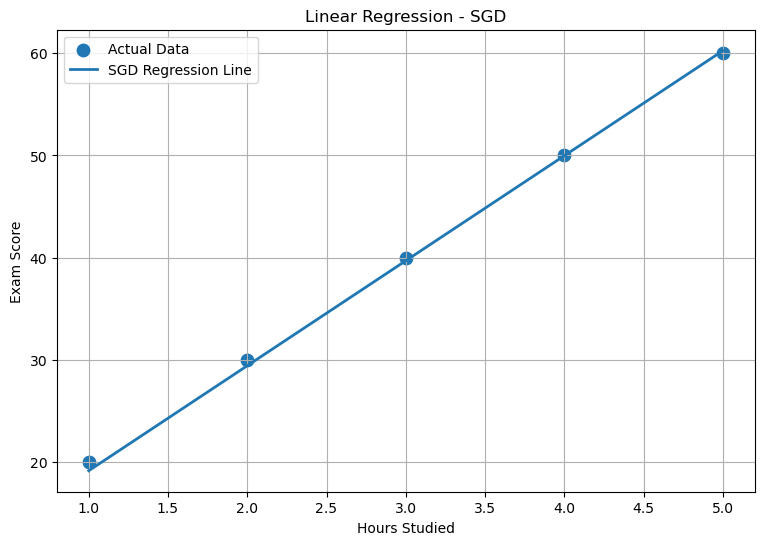

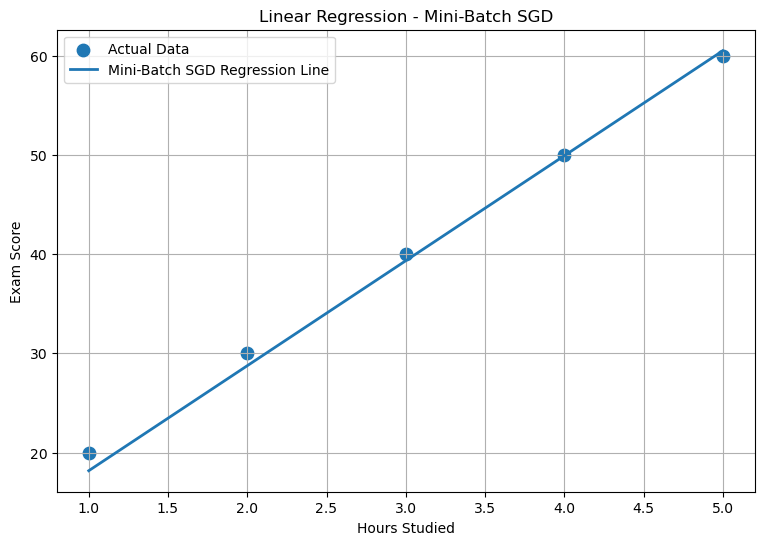

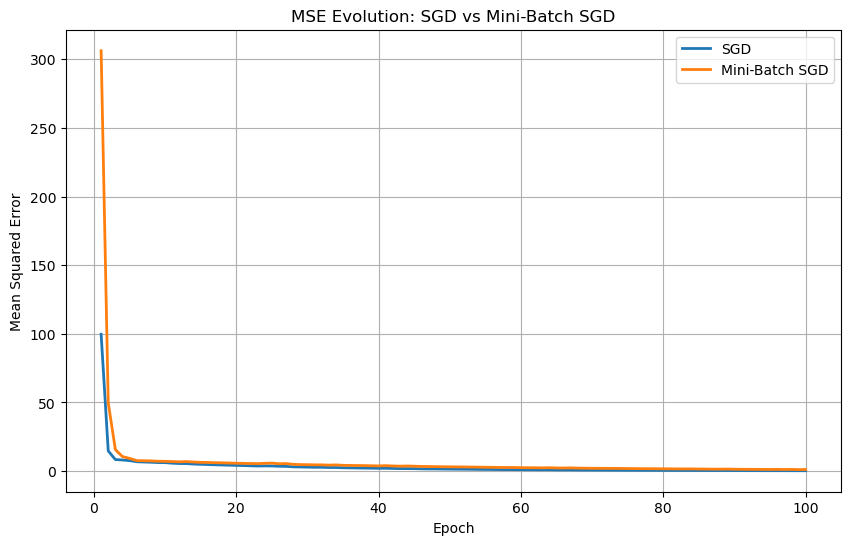

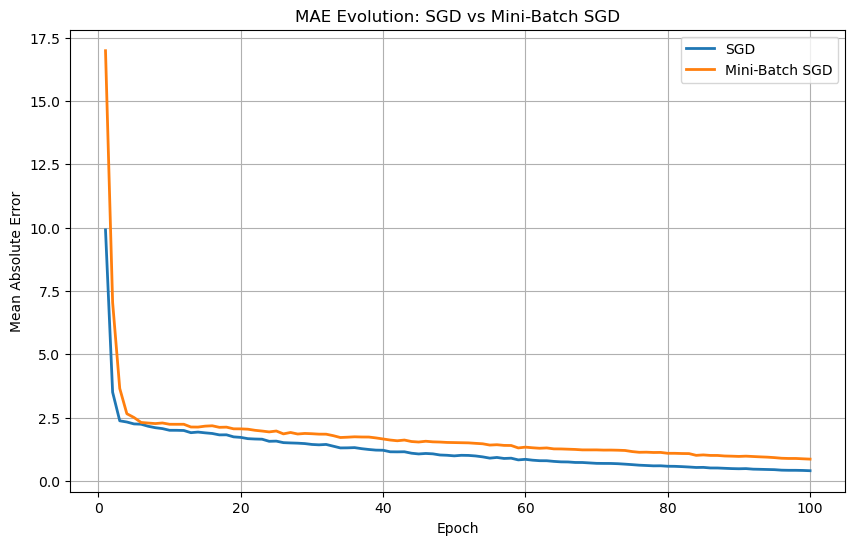

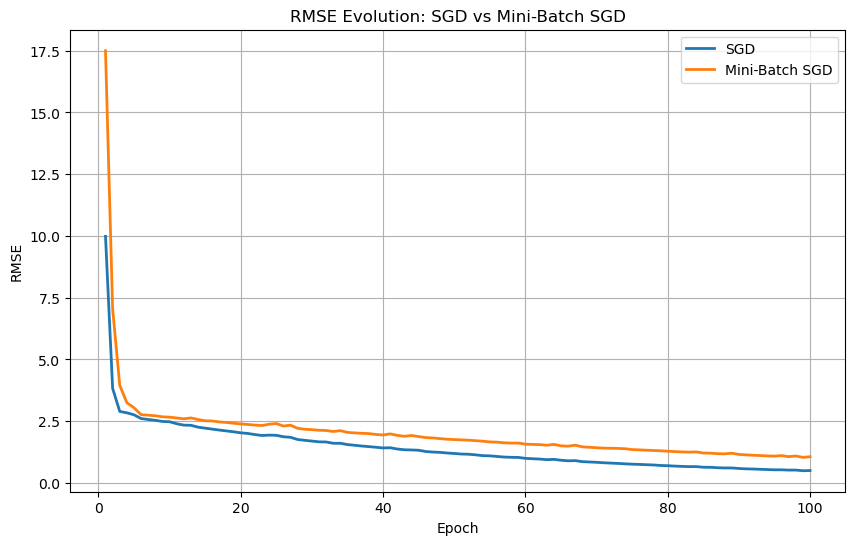

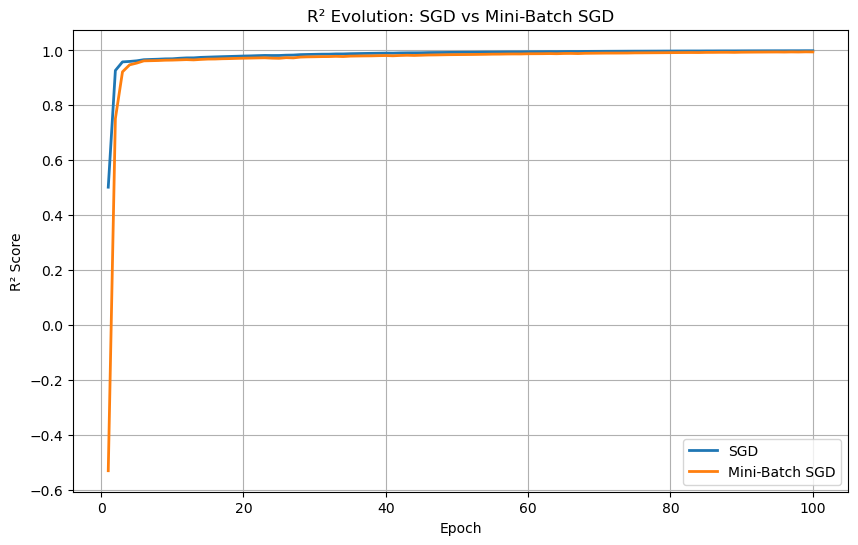

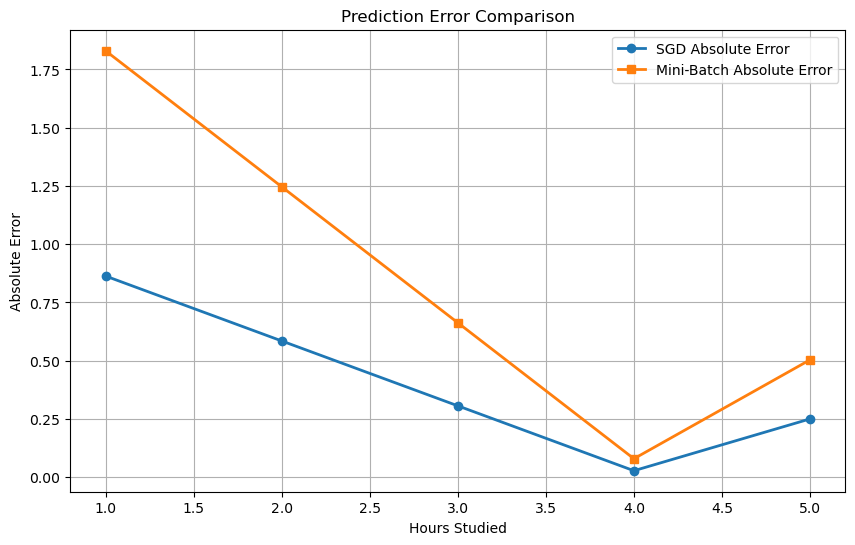

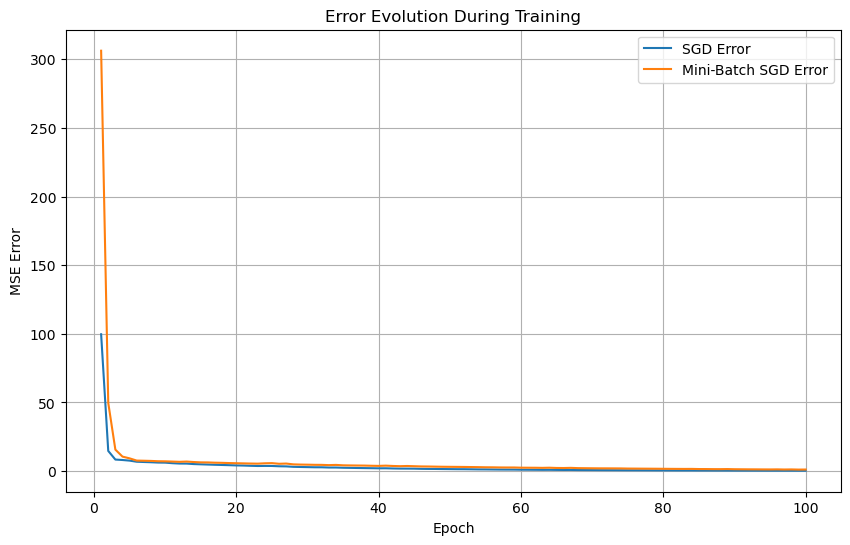



                         TRAINING COMPLETED

Both SGD and Mini-Batch SGD have been trained and compared.

The graphs show:
1. SGD regression line
2. Mini-Batch SGD regression line
3. MSE evolution
4. MAE evolution
5. RMSE evolution
6. R² evolution
7. Absolute prediction error
8. Error reduction during training



In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time


# ============================================================
# 1. DATASET
# ============================================================

X = np.array([1, 2, 3, 4, 5], dtype=float)
y = np.array([20, 30, 40, 50, 60], dtype=float)

learning_rate = 0.01
epochs = 100

# SGD
sgd_batch_size = 1

# Mini-Batch SGD
mini_batch_size = 2

# New prediction
hours = 6


# ============================================================
# 2. HELPER FUNCTION FOR METRICS
# ============================================================

def calculate_metrics(y_true, y_pred):

    error = y_pred - y

    mse = np.mean(error ** 2)

    mae = np.mean(np.abs(error))

    rmse = np.sqrt(mse)

    ss_res = np.sum((y_true - y_pred) ** 2)

    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)

    r2 = 1 - (ss_res / ss_tot)

    # Mean Absolute Percentage Error
    mape = np.mean(
        np.abs((y_true - y_pred) / y_true)
    ) * 100

    return mse, mae, rmse, r2, mape


# ============================================================
# 3. TRAINING FUNCTION
# ============================================================

def train_model(
    X,
    y,
    learning_rate,
    epochs,
    batch_size,
    epoch_shuffles
):

    # Initial parameters
    w = 0.0
    b = 0.0

    # History
    mse_history = []
    mae_history = []
    rmse_history = []
    r2_history = []
    mape_history = []

    # Count parameter updates
    update_count = 0

    # Start timer
    start_time = time.perf_counter()

    for epoch in range(epochs):

        # Use the same shuffle for both models
        indices = epoch_shuffles[epoch]

        X_shuffled = X[indices]
        y_shuffled = y[indices]

        # ----------------------------------------------------
        # MINI-BATCH LOOP
        # ----------------------------------------------------

        for i in range(0, len(X), batch_size):

            X_batch = X_shuffled[i:i + batch_size]
            y_batch = y_shuffled[i:i + batch_size]

            # Prediction
            y_pred_batch = w * X_batch + b

            # Error
            error_batch = y_pred_batch - y_batch

            # Gradient of MSE with respect to w
            dw = np.mean(
                2 * X_batch * error_batch
            )

            # Gradient of MSE with respect to b
            db = np.mean(
                2 * error_batch
            )

            # Update parameters
            w = w - learning_rate * dw
            b = b - learning_rate * db

            update_count += 1

        # ----------------------------------------------------
        # CALCULATE METRICS AFTER EACH EPOCH
        # ----------------------------------------------------

        y_pred_all = w * X + b

        mse, mae, rmse, r2, mape = calculate_metrics(
            y,
            y_pred_all
        )

        mse_history.append(mse)
        mae_history.append(mae)
        rmse_history.append(rmse)
        r2_history.append(r2)
        mape_history.append(mape)

    end_time = time.perf_counter()

    training_time = end_time - start_time

    # Final prediction
    y_pred_final = w * X + b

    # Final metrics
    mse, mae, rmse, r2, mape = calculate_metrics(
        y,
        y_pred_final
    )

    return {
        "w": w,
        "b": b,
        "y_pred": y_pred_final,

        "mse": mse,
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "mape": mape,

        "mse_history": mse_history,
        "mae_history": mae_history,
        "rmse_history": rmse_history,
        "r2_history": r2_history,
        "mape_history": mape_history,

        "updates": update_count,
        "training_time": training_time
    }


# ============================================================
# 4. CREATE SAME SHUFFLES FOR BOTH MODELS
# ============================================================

np.random.seed(42)

epoch_shuffles = []

for epoch in range(epochs):

    indices = np.random.permutation(len(X))

    epoch_shuffles.append(indices)


# ============================================================
# 5. TRAIN SGD
# ============================================================

print("\nTraining SGD...")

sgd_result = train_model(
    X,
    y,
    learning_rate,
    epochs,
    sgd_batch_size,
    epoch_shuffles
)


# ============================================================
# 6. TRAIN MINI-BATCH SGD
# ============================================================

print("Training Mini-Batch SGD...")

mini_result = train_model(
    X,
    y,
    learning_rate,
    epochs,
    mini_batch_size,
    epoch_shuffles
)


# ============================================================
# 7. BASIC INFORMATION
# ============================================================

dataset_size = len(X)

sgd_updates_per_epoch = int(
    np.ceil(dataset_size / sgd_batch_size)
)

mini_updates_per_epoch = int(
    np.ceil(dataset_size / mini_batch_size)
)


# ============================================================
# 8. MAIN HEADER
# ============================================================

print("\n")
print("=" * 90)
print("           SGD vs MINI-BATCH SGD - LINEAR REGRESSION")
print("=" * 90)


# ============================================================
# 9. DATASET INFORMATION
# ============================================================

print("\nDATASET INFORMATION")
print("-" * 90)

print("Input X                  :", X)
print("Actual Y                 :", y)
print("Dataset Size             :", dataset_size)

print("\nTraining Parameters")
print("-" * 90)

print("Learning Rate            :", learning_rate)
print("Epochs                   :", epochs)

print("\nSGD")
print("-" * 90)

print("Batch Size               :", sgd_batch_size)
print("Updates per Epoch        :", sgd_updates_per_epoch)
print("Total Parameter Updates  :", sgd_result["updates"])

print("\nMini-Batch SGD")
print("-" * 90)

print("Batch Size               :", mini_batch_size)
print("Updates per Epoch        :", mini_updates_per_epoch)
print("Total Parameter Updates  :", mini_result["updates"])


# ============================================================
# 10. PERFORMANCE EVERY 50 EPOCHS
# ============================================================

print("\n")
print("=" * 90)
print("                 PERFORMANCE EVERY 50 EPOCHS")
print("=" * 90)

print(
    f"{'Epoch':<10}"
    f"{'SGD MSE':<15}"
    f"{'Mini MSE':<15}"
    f"{'SGD MAE':<15}"
    f"{'Mini MAE':<15}"
)

print("-" * 90)

for epoch in range(50, epochs + 1, 50):

    index = epoch - 1

    print(
        f"{epoch:<10}"
        f"{sgd_result['mse_history'][index]:<15.6f}"
        f"{mini_result['mse_history'][index]:<15.6f}"
        f"{sgd_result['mae_history'][index]:<15.6f}"
        f"{mini_result['mae_history'][index]:<15.6f}"
    )


# ============================================================
# 11. R2 EVERY 50 EPOCHS
# ============================================================

print("\n")
print("=" * 90)
print("                    R² EVERY 50 EPOCHS")
print("=" * 90)

print(
    f"{'Epoch':<10}"
    f"{'SGD R²':<20}"
    f"{'Mini-Batch R²':<20}"
)

print("-" * 90)

for epoch in range(50, epochs + 1, 50):

    index = epoch - 1

    print(
        f"{epoch:<10}"
        f"{sgd_result['r2_history'][index]:<20.6f}"
        f"{mini_result['r2_history'][index]:<20.6f}"
    )


# ============================================================
# 12. FINAL PARAMETERS
# ============================================================

print("\n")
print("=" * 90)
print("                    FINAL MODEL PARAMETERS")
print("=" * 90)

print("\nSGD")
print("-" * 90)

print(f"Weight (w)              : {sgd_result['w']:.10f}")
print(f"Bias (b)                : {sgd_result['b']:.10f}")

print(
    f"Equation                : "
    f"y = {sgd_result['w']:.6f}x + {sgd_result['b']:.6f}"
)


print("\nMini-Batch SGD")
print("-" * 90)

print(f"Weight (w)              : {mini_result['w']:.10f}")
print(f"Bias (b)                : {mini_result['b']:.10f}")

print(
    f"Equation                : "
    f"y = {mini_result['w']:.6f}x + {mini_result['b']:.6f}"
)


# ============================================================
# 13. DETAILED PREDICTIONS - SGD
# ============================================================

print("\n")
print("=" * 90)
print("                         SGD PREDICTIONS")
print("=" * 90)

print(
    f"{'Input':<10}"
    f"{'Actual':<12}"
    f"{'Predicted':<15}"
    f"{'Error':<15}"
    f"{'Abs Error':<15}"
    f"{'Squared Error':<18}"
)

print("-" * 90)

sgd_errors = sgd_result["y_pred"] - y

for i in range(dataset_size):

    error = sgd_errors[i]

    print(
        f"{X[i]:<10.2f}"
        f"{y[i]:<12.2f}"
        f"{sgd_result['y_pred'][i]:<15.6f}"
        f"{error:<15.6f}"
        f"{abs(error):<15.6f}"
        f"{error ** 2:<18.6f}"
    )


# ============================================================
# 14. DETAILED PREDICTIONS - MINI-BATCH
# ============================================================

print("\n")
print("=" * 90)
print("                    MINI-BATCH SGD PREDICTIONS")
print("=" * 90)

print(
    f"{'Input':<10}"
    f"{'Actual':<12}"
    f"{'Predicted':<15}"
    f"{'Error':<15}"
    f"{'Abs Error':<15}"
    f"{'Squared Error':<18}"
)

print("-" * 90)

mini_errors = mini_result["y_pred"] - y

for i in range(dataset_size):

    error = mini_errors[i]

    print(
        f"{X[i]:<10.2f}"
        f"{y[i]:<12.2f}"
        f"{mini_result['y_pred'][i]:<15.6f}"
        f"{error:<15.6f}"
        f"{abs(error):<15.6f}"
        f"{error ** 2:<18.6f}"
    )


# ============================================================
# 15. FINAL PERFORMANCE COMPARISON
# ============================================================

print("\n")
print("=" * 90)
print("                     FINAL PERFORMANCE COMPARISON")
print("=" * 90)

print(
    f"{'Metric':<25}"
    f"{'SGD':<20}"
    f"{'Mini-Batch SGD':<20}"
)

print("-" * 90)

print(
    f"{'MSE':<25}"
    f"{sgd_result['mse']:<20.8f}"
    f"{mini_result['mse']:<20.8f}"
)

print(
    f"{'MAE':<25}"
    f"{sgd_result['mae']:<20.8f}"
    f"{mini_result['mae']:<20.8f}"
)

print(
    f"{'RMSE':<25}"
    f"{sgd_result['rmse']:<20.8f}"
    f"{mini_result['rmse']:<20.8f}"
)

print(
    f"{'R² Score':<25}"
    f"{sgd_result['r2']:<20.8f}"
    f"{mini_result['r2']:<20.8f}"
)

print(
    f"{'MAPE (%)':<25}"
    f"{sgd_result['mape']:<20.8f}"
    f"{mini_result['mape']:<20.8f}"
)

print(
    f"{'Training Time (sec)':<25}"
    f"{sgd_result['training_time']:<20.8f}"
    f"{mini_result['training_time']:<20.8f}"
)

print(
    f"{'Parameter Updates':<25}"
    f"{sgd_result['updates']:<20}"
    f"{mini_result['updates']:<20}"
)


# ============================================================
# 16. ERROR REDUCTION COMPARISON
# ============================================================

print("\n")
print("=" * 90)
print("                       ERROR REDUCTION")
print("=" * 90)

print(
    f"SGD Final MSE          : {sgd_result['mse']:.8f}"
)

print(
    f"Mini-Batch Final MSE   : {mini_result['mse']:.8f}"
)

mse_difference = (
    abs(sgd_result["mse"] - mini_result["mse"])
)

print(
    f"Difference in MSE      : {mse_difference:.8f}"
)


# ============================================================
# 17. DETERMINE BETTER MODEL
# ============================================================

if sgd_result["mse"] < mini_result["mse"]:

    print("\nBased on MSE:")
    print("SGD performed better.")

elif mini_result["mse"] < sgd_result["mse"]:

    print("\nBased on MSE:")
    print("Mini-Batch SGD performed better.")

else:

    print("\nBased on MSE:")
    print("Both methods performed equally.")


if sgd_result["r2"] > mini_result["r2"]:

    print("Based on R²:")
    print("SGD performed better.")

elif mini_result["r2"] > sgd_result["r2"]:

    print("Based on R²:")
    print("Mini-Batch SGD performed better.")

else:

    print("Based on R²:")
    print("Both methods performed equally.")


# ============================================================
# 18. NEW PREDICTION FOR 6 HOURS
# ============================================================

sgd_prediction = (
    sgd_result["w"] * hours +
    sgd_result["b"]
)

mini_prediction = (
    mini_result["w"] * hours +
    mini_result["b"]
)


print("\n")
print("=" * 90)
print("                    NEW DATA PREDICTION")
print("=" * 90)

print(f"Hours Studied          : {hours}")

print(
    f"SGD Prediction         : "
    f"{sgd_prediction:.6f}"
)

print(
    f"Mini-Batch Prediction  : "
    f"{mini_prediction:.6f}"
)


# ============================================================
# 19. MAJOR COMPARISON
# ============================================================

print("\n")
print("=" * 90)
print("                         MAJOR COMPARISON")
print("=" * 90)

print("""
SGD:
-----
• Batch size = 1
• Uses one training sample for each update
• More frequent parameter updates
• More noisy gradient updates
• 5 updates per epoch
• 500 updates in 100 epochs


Mini-Batch SGD:
---------------
• Batch size = 2
• Uses two samples for most updates
• Gradients are averaged within each batch
• More stable updates than SGD
• 3 updates per epoch
• 300 updates in 100 epochs


GENERAL OBSERVATION:
--------------------
SGD updates the parameters more frequently because
it processes one sample at a time.

Mini-Batch SGD performs fewer updates because it
processes multiple samples before updating the parameters.

For larger real-world datasets, Mini-Batch SGD is usually
preferred because it provides a balance between the noisy
updates of SGD and the expensive full-batch approach.
""")


# ============================================================
# 20. GRAPH 1 - ACTUAL VS SGD
# ============================================================

plt.figure(figsize=(9, 6))

plt.scatter(
    X,
    y,
    s=80,
    label="Actual Data"
)

plt.plot(
    X,
    sgd_result["y_pred"],
    linewidth=2,
    label="SGD Regression Line"
)

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Linear Regression - SGD")
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 21. GRAPH 2 - ACTUAL VS MINI-BATCH
# ============================================================

plt.figure(figsize=(9, 6))

plt.scatter(
    X,
    y,
    s=80,
    label="Actual Data"
)

plt.plot(
    X,
    mini_result["y_pred"],
    linewidth=2,
    label="Mini-Batch SGD Regression Line"
)

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Linear Regression - Mini-Batch SGD")
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 22. GRAPH 3 - MSE EVOLUTION
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, epochs + 1),
    sgd_result["mse_history"],
    linewidth=2,
    label="SGD"
)

plt.plot(
    range(1, epochs + 1),
    mini_result["mse_history"],
    linewidth=2,
    label="Mini-Batch SGD"
)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("MSE Evolution: SGD vs Mini-Batch SGD")
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 23. GRAPH 4 - MAE EVOLUTION
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, epochs + 1),
    sgd_result["mae_history"],
    linewidth=2,
    label="SGD"
)

plt.plot(
    range(1, epochs + 1),
    mini_result["mae_history"],
    linewidth=2,
    label="Mini-Batch SGD"
)

plt.xlabel("Epoch")
plt.ylabel("Mean Absolute Error")
plt.title("MAE Evolution: SGD vs Mini-Batch SGD")
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 24. GRAPH 5 - RMSE EVOLUTION
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, epochs + 1),
    sgd_result["rmse_history"],
    linewidth=2,
    label="SGD"
)

plt.plot(
    range(1, epochs + 1),
    mini_result["rmse_history"],
    linewidth=2,
    label="Mini-Batch SGD"
)

plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("RMSE Evolution: SGD vs Mini-Batch SGD")
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 25. GRAPH 6 - R2 EVOLUTION
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, epochs + 1),
    sgd_result["r2_history"],
    linewidth=2,
    label="SGD"
)

plt.plot(
    range(1, epochs + 1),
    mini_result["r2_history"],
    linewidth=2,
    label="Mini-Batch SGD"
)

plt.xlabel("Epoch")
plt.ylabel("R² Score")
plt.title("R² Evolution: SGD vs Mini-Batch SGD")
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 26. GRAPH 7 - ABSOLUTE ERROR COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    X,
    np.abs(sgd_errors),
    marker="o",
    linewidth=2,
    label="SGD Absolute Error"
)

plt.plot(
    X,
    np.abs(mini_errors),
    marker="s",
    linewidth=2,
    label="Mini-Batch Absolute Error"
)

plt.xlabel("Hours Studied")
plt.ylabel("Absolute Error")
plt.title("Prediction Error Comparison")
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 27. GRAPH 8 - ERROR EVOLUTION
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, epochs + 1),
    sgd_result["mse_history"],
    label="SGD Error"
)

plt.plot(
    range(1, epochs + 1),
    mini_result["mse_history"],
    label="Mini-Batch SGD Error"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Error")
plt.title("Error Evolution During Training")
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 28. FINAL MESSAGE
# ============================================================

print("\n")
print("=" * 90)
print("                         TRAINING COMPLETED")
print("=" * 90)

print("""
Both SGD and Mini-Batch SGD have been trained and compared.

The graphs show:
1. SGD regression line
2. Mini-Batch SGD regression line
3. MSE evolution
4. MAE evolution
5. RMSE evolution
6. R² evolution
7. Absolute prediction error
8. Error reduction during training
""")